# CUDA Basics: GPU Memory Hierarchy, Warps, and Occupancy

This notebook builds the mental model you need before reading kernel code (Triton, FlashAttention, custom CUDA) or interpreting profiler output. We'll cover **what a GPU actually is**, **why memory hierarchy dominates LLM performance**, and **how the execution model (threads → warps → blocks → grid) maps to the hardware**.

By the end, you should be able to answer:

- Why is FlashAttention faster than vanilla attention if it does *more* FLOPs? ([Dao et al., 2022](https://arxiv.org/abs/2205.14135))
- Why does a 7B-param LLM at long context become **memory-bandwidth-bound**, not compute-bound, during decode?
- What does "MFU = 45%" actually measure, and why is 100% impossible? (See `src/ai_playground/profiling/flops.py`.)

### Concepts covered

| # | Concept | Section |
|---|---------|---------|
| 1 | GPU vs CPU: throughput vs latency hardware | §1 |
| 2 | Memory hierarchy (registers → SRAM → L2 → HBM) | §2 |
| 3 | Bandwidth wall and the roofline model | §3 |
| 4 | SIMT execution: threads, warps, blocks, grids | §4 |
| 5 | Occupancy and latency hiding | §5 |
| 6 | Writing a first CUDA kernel (Numba) | §6 |
| 7 | Coalesced memory access | §7 |
| 8 | Why this matters for LLMs (FlashAttention, GEMM, MFU) | §8 |

See also: [docs/LEARNING_PATH.md § Phase 5](../../docs/LEARNING_PATH.md) · [docs/PAPERS.md § Inference Optimization](../../docs/PAPERS.md) · [PMPP textbook](https://shop.elsevier.com/books/programming-massively-parallel-processors/hwu/978-0-323-91231-0) (Hwu, Kirk, Hajj — the standard reference)

::: {.callout-tip title="📺 Video companion"}
[How CUDA Programming Works (Stephen Jones, GTC 2022)](https://www.youtube.com/watch?v=QQceTDjA4f4) builds exactly the mental model this notebook covers — memory bandwidth as the real constraint, warps, and occupancy — straight from a CUDA architect — more in [Videos](../../docs/VIDEOS.md).
:::

::: {.callout-note title="🎯 Goal"}
Build the GPU mental model: memory hierarchy, warps, occupancy, coalescing — and why LLM decode is bandwidth-bound.

🏗️ **Chapter milestone:** M9 — place your model's decode on the T4 roofline — the exercise at the end of this chapter; see [The Project](../../docs/PROJECT.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/05_gpu_nvidia_tools/01_cuda_basics.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

The kernel cells need an NVIDIA GPU: on Colab pick *Runtime → Change runtime type → T4 GPU*. Without one, the notebook still runs — kernel cells fall back to illustrations.

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

In [2]:
import sys
sys.path.insert(0, '../src')

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
HAS_CUDA = torch.cuda.is_available()
print(f'Device: {device}')
if HAS_CUDA:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Compute capability: {torch.cuda.get_device_capability(0)}')
else:
    print('No CUDA GPU — kernel cells will be illustrative.')
    print('To run for real: see docs/CLOUD_SETUP.md.')

Device: mps
No CUDA GPU — kernel cells will be illustrative.
To run for real: see docs/CLOUD_SETUP.md.


## 1. GPU vs CPU: throughput vs latency hardware

A modern CPU core is optimized to finish **one** sequential thread fast: deep pipelines, branch prediction, large per-core caches, out-of-order execution. A GPU SM (Streaming Multiprocessor) is the opposite — it's optimized to keep **thousands** of threads in flight so it can hide memory latency by always having other work to do.

Concrete numbers (H100 SXM vs a high-end CPU):

| | CPU (e.g. EPYC 9654) | H100 SXM |
|--|--|--|
| Cores / SMs | 96 cores | 132 SMs |
| Threads in flight | ~192 (2 per core) | ~270,000 (2,048 per SM) |
| Peak FP32 throughput | ~5 TFLOPS | 67 TFLOPS |
| Peak BF16 tensor cores | — | 989 TFLOPS |
| Memory bandwidth | ~460 GB/s (DDR5) | 3,350 GB/s (HBM3) |

The GPU has ~7x the bandwidth and ~200x the BF16 throughput, but each individual thread is *slower* than a CPU thread. **GPUs win by parallelism, not single-thread speed.**

This shapes everything that follows. If you can't expose enough parallel work, or if your work pattern fights the memory system, you'll get a fraction of peak.

## 2. Memory hierarchy

The most important fact about a GPU isn't its FLOPS — it's that **memory is structured as a hierarchy with orders-of-magnitude bandwidth differences between levels**. Understanding this is the difference between "my kernel is slow and I don't know why" and "I can read FlashAttention and explain every choice."

For an H100:

| Level | Size | Bandwidth | Latency | Scope |
|-------|------|-----------|---------|-------|
| Registers | 256 KB / SM | ~20 TB/s effectively | ~1 cycle | per-thread |
| Shared memory (SRAM) | 228 KB / SM | ~19 TB/s | ~30 cycles | per-block |
| L2 cache | 50 MB | ~5.5 TB/s | ~200 cycles | device-wide |
| HBM (global memory) | 80 GB | 3.35 TB/s | ~500 cycles | device-wide |

A few takeaways:

- **SRAM is ~6x faster than HBM.** This is the single number behind FlashAttention's ~2-4x speedup: it tiles attention so Q, K, V tiles live in SRAM during the softmax+matmul, instead of the whole `n × n` score matrix being written to HBM.
- **Registers are private to a thread.** They hold the values you're actively computing on.
- **Shared memory is per-block, programmer-managed.** Unlike CPU cache, *you* decide what goes there. This is the main lever for kernel optimization.
- **HBM is huge but slow.** Every load from global memory is ~500 cycles of latency. Hiding this latency requires having lots of other warps ready to run (§5).

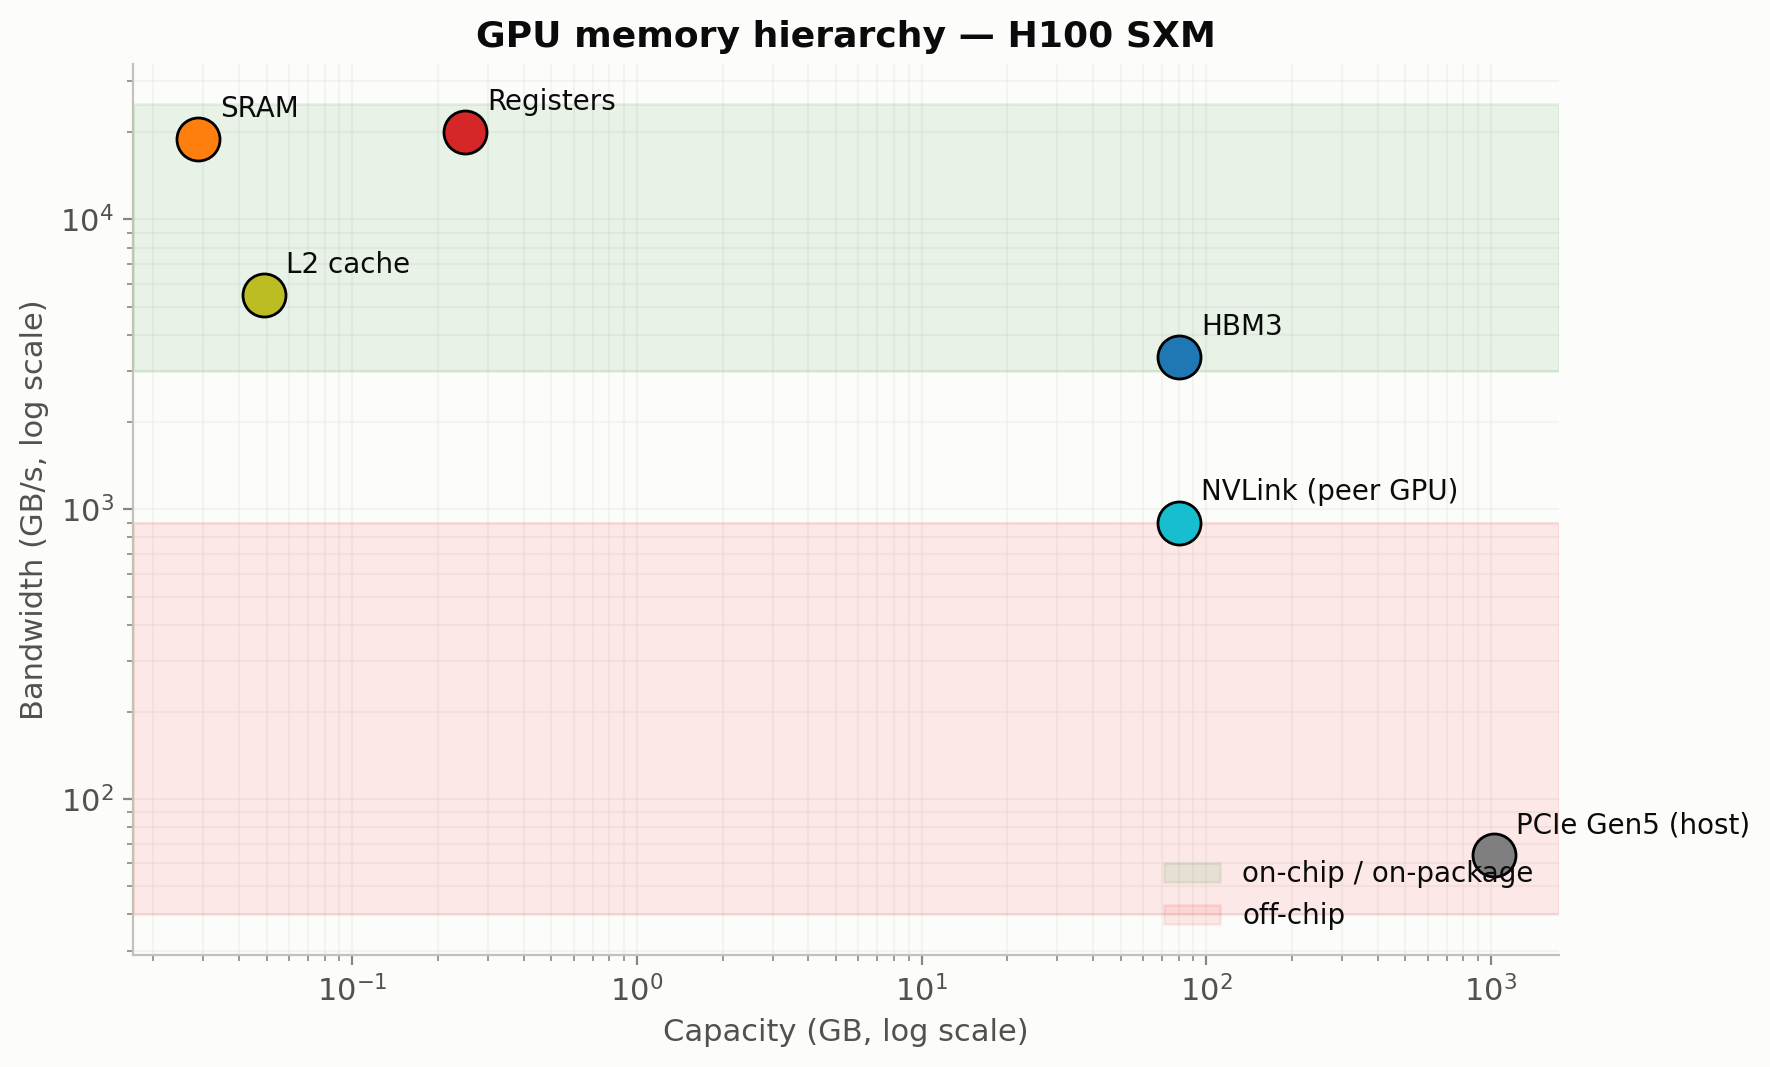

Rule of thumb: every step DOWN the hierarchy is ~5-10x slower bandwidth.
A kernel that touches HBM 10x more than necessary will be ~10x slower than it should be.


In [3]:
# Visualize the memory hierarchy: capacity (log) vs bandwidth (log).
levels = [
    ('Registers',  256 / 1024,        20_000, 'tab:red'),       # GB, GB/s
    ('SRAM',       228 / 1024 / 1024 * 132, 19_000, 'tab:orange'),
    ('L2 cache',   50 / 1024,         5_500,  'tab:olive'),
    ('HBM3',       80,                3_350,  'tab:blue'),
    ('NVLink (peer GPU)', 80,         900,    'tab:cyan'),
    ('PCIe Gen5 (host)',  1024,       64,     'tab:gray'),
]

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, cap_gb, bw_gbs, color in levels:
    ax.scatter(cap_gb, bw_gbs, s=240, color=color, edgecolor='black', zorder=3)
    ax.annotate(name, (cap_gb, bw_gbs), xytext=(8, 8), textcoords='offset points', fontsize=10)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Capacity (GB, log scale)')
ax.set_ylabel('Bandwidth (GB/s, log scale)')
ax.set_title('GPU memory hierarchy — H100 SXM')
ax.grid(True, which='both', alpha=0.3)
ax.axhspan(3000, 25000, alpha=0.08, color='green', label='on-chip / on-package')
ax.axhspan(40, 900, alpha=0.08, color='red', label='off-chip')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Rule of thumb: every step DOWN the hierarchy is ~5-10x slower bandwidth.')
print('A kernel that touches HBM 10x more than necessary will be ~10x slower than it should be.')

## 3. The bandwidth wall and the roofline model

Whether a kernel is **compute-bound** or **memory-bound** depends on its **arithmetic intensity**:

$$\text{AI} = \frac{\text{FLOPs performed}}{\text{bytes moved from HBM}}$$

The **roofline model** ([Williams et al., 2009](https://dl.acm.org/doi/10.1145/1498765.1498785)) plots achievable performance vs arithmetic intensity. Below the "ridge point", you're limited by bandwidth (`AI × peak_BW`); above it, by peak FLOPS.

For an H100 (BF16 tensor cores, 989 TFLOPS peak, 3,350 GB/s HBM):

$$\text{ridge} = \frac{989 \times 10^{12}}{3.35 \times 10^{12}} \approx 295 \text{ FLOPs/byte}$$

So you need ~295 FLOPs per byte read from HBM just to *not* be bandwidth-bound. That's a high bar.

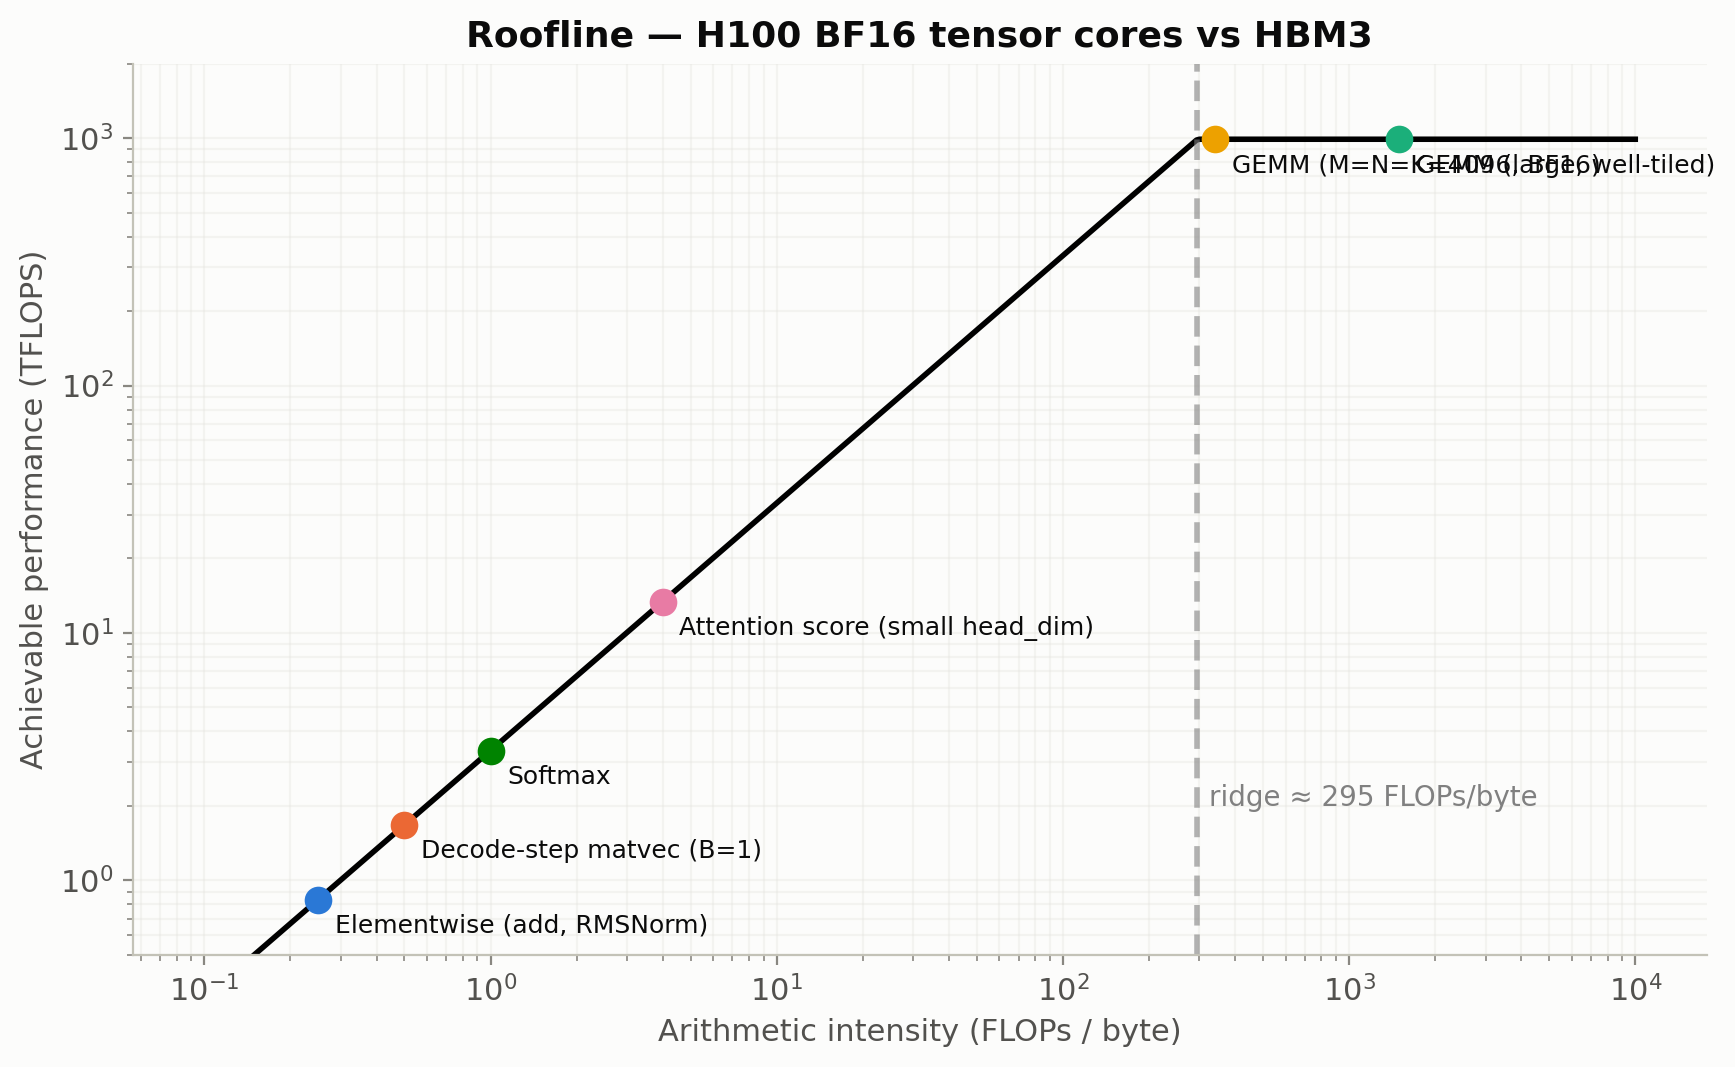

Notice: most LLM ops EXCEPT large GEMMs are bandwidth-bound on modern GPUs.
This is why fusing elementwise ops (RMSNorm + residual + ...) matters so much.
It is also why decode (B=1) tops out at ~5-10% MFU even for perfect kernels.


In [4]:
# Roofline plot for H100 BF16, with common LLM ops marked.
peak_tflops = 989       # BF16 tensor cores
peak_bw_tbs = 3.35      # HBM3
ridge = peak_tflops / peak_bw_tbs
ai = np.logspace(-1, 4, 500)
perf = np.minimum(ai * peak_bw_tbs, peak_tflops)

ops = [
    # (label, arithmetic intensity FLOPs/byte, achieved-ish TFLOPS)
    ('Elementwise (add, RMSNorm)', 0.25,  None),
    ('Softmax',                    1.0,   None),
    ('Attention score (small head_dim)', 4.0, None),
    ('GEMM (M=N=K=4096, BF16)',    340,   None),
    ('GEMM (large, well-tiled)',   1500,  None),
    ('Decode-step matvec (B=1)',   0.5,   None),  # purely memory bound
]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(ai, perf, 'k-', linewidth=2)
ax.axvline(ridge, color='gray', linestyle='--', alpha=0.6)
ax.text(ridge * 1.1, 2, f'ridge ≈ {ridge:.0f} FLOPs/byte', fontsize=10, color='gray')

for label, x, _ in ops:
    y = min(x * peak_bw_tbs, peak_tflops)
    ax.scatter(x, y, s=80, zorder=3)
    ax.annotate(label, (x, y), xytext=(6, -12), textcoords='offset points', fontsize=9)

ax.set_xlabel('Arithmetic intensity (FLOPs / byte)')
ax.set_ylabel('Achievable performance (TFLOPS)')
ax.set_title('Roofline — H100 BF16 tensor cores vs HBM3')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0.5, 2000)
plt.tight_layout()
plt.show()

print('Notice: most LLM ops EXCEPT large GEMMs are bandwidth-bound on modern GPUs.')
print('This is why fusing elementwise ops (RMSNorm + residual + ...) matters so much.')
print('It is also why decode (B=1) tops out at ~5-10% MFU even for perfect kernels.')

## 4. SIMT execution: threads → warps → blocks → grid

CUDA's programming model is **SIMT** (Single Instruction, Multiple Threads). You write code from the perspective of one thread, but the hardware runs them in lockstep groups.

```
grid          = many blocks (your problem, e.g. 1M elements)
  └── block   = group of threads scheduled together on one SM (e.g. 256 threads)
        └── warp = 32 threads executing the same instruction in lockstep
              └── thread = one execution lane, with its own registers
```

Key facts:

- **A warp is always 32 threads on NVIDIA hardware.** This is a hardware constant, not a tuning knob.
- **All 32 threads in a warp execute the same instruction every cycle.** If they branch differently (`if`/`else`), the GPU executes both paths serially with the inactive lanes masked out — this is "warp divergence" and it costs performance.
- **Blocks are scheduled to one SM and can use shared memory to cooperate.** Threads in different blocks can't share fast memory — only HBM or atomics.
- **Block size should be a multiple of 32.** Common choices: 128, 256, 512. Below 32 wastes lanes; above 1024 isn't allowed.

When you write `kernel<<<grid_dim, block_dim>>>(...)` you're saying: launch `grid_dim × block_dim` total threads, organized as `grid_dim` blocks of `block_dim` threads each.

## 5. Occupancy and latency hiding

Recall HBM latency is ~500 cycles. If a warp issues a load, what does the SM do for the next 500 cycles? **It runs other warps.** That's the entire trick.

**Occupancy** = (active warps per SM) / (max warps per SM). On an H100, max is 64 warps/SM = 2,048 threads/SM. Higher occupancy generally hides memory latency better — but there are tradeoffs:

- **Registers per thread** is finite (255 max, ~64K total per SM). More registers per thread → fewer threads can fit → lower occupancy.
- **Shared memory per block** is finite (228 KB on H100). Bigger tiles → fewer blocks per SM → lower occupancy.
- **Higher occupancy isn't always better.** Volkov's classic talk ["Better Performance at Lower Occupancy"](https://www.nvidia.com/content/gtc-2010/pdfs/2238_gtc2010.pdf) shows that for arithmetic-heavy kernels, putting more work *per thread* (using more registers) can beat raw occupancy.

For LLMs, the practical heuristics:

- Aim for ≥50% occupancy as a starting point.
- If you're memory-bound (most of attention, RMSNorm, etc.), occupancy matters a lot.
- If you're compute-bound (large GEMMs), tensor cores already saturate — occupancy matters less.
- The CUDA Occupancy Calculator and `nsys`/`ncu` (covered in `03_nsight_profiling.ipynb`) will tell you what's actually limiting you.

## 6. A first CUDA kernel: vector add

Let's actually write one. Vector add is the "hello world" of GPU programming — every thread reads one element of `a` and `b`, writes one element of `c`. Embarrassingly parallel, ~zero arithmetic intensity, purely memory-bound.

We'll use **Numba's `@cuda.jit`** because it lets us stay in Python. (Triton — covered in `02_triton_kernels.ipynb` — is the modern choice for production kernels, but Numba is the gentlest first step.)

The kernel runs only if you have CUDA; otherwise we describe what it would do.

In [5]:
# Numba CUDA vector-add kernel. Falls back to a description if no CUDA.
KERNEL_SRC = '''
@cuda.jit
def vector_add(a, b, c):
    # Each thread computes one output element.
    # `cuda.grid(1)` returns this thread's global 1D index.
    i = cuda.grid(1)
    if i < a.size:
        c[i] = a[i] + b[i]
'''
print('Kernel source:')
print(KERNEL_SRC)

if HAS_CUDA:
    try:
        from numba import cuda
        import numba
        import math

        @cuda.jit
        def vector_add(a, b, c):
            i = cuda.grid(1)
            if i < a.size:
                c[i] = a[i] + b[i]

        N = 1 << 24  # 16M elements
        a = np.random.randn(N).astype(np.float32)
        b = np.random.randn(N).astype(np.float32)
        c = np.zeros_like(a)

        d_a = cuda.to_device(a)
        d_b = cuda.to_device(b)
        d_c = cuda.to_device(c)

        threads_per_block = 256
        blocks_per_grid = math.ceil(N / threads_per_block)
        print(f'Launching {blocks_per_grid} blocks x {threads_per_block} threads = {blocks_per_grid * threads_per_block:,} threads')
        print(f'  Total warps: {blocks_per_grid * threads_per_block // 32:,}')

        # Warmup + time
        vector_add[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
        cuda.synchronize()
        start = cuda.event(); end = cuda.event()
        start.record()
        for _ in range(50):
            vector_add[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
        end.record(); end.synchronize()
        ms = cuda.event_elapsed_time(start, end) / 50

        bytes_moved = 3 * N * 4  # read a, read b, write c — fp32
        bw = bytes_moved / (ms * 1e-3) / 1e9
        print(f'\nKernel time: {ms:.3f} ms')
        print(f'Effective bandwidth: {bw:.1f} GB/s')
        print('(Compare to your GPU peak — vector add should hit 70-90% of peak HBM bandwidth.)')
    except ImportError:
        print('Numba not installed. `uv pip install numba` to run for real.')
else:
    print('No CUDA — but here is what would happen:')
    print('  - 16M elements, 256 threads/block → 65,536 blocks')
    print('  - Each thread reads 8 bytes (a[i] + b[i]), writes 4 bytes')
    print('  - Total: 12 bytes per element x 16M = 192 MB of HBM traffic')
    print('  - On H100 (3.35 TB/s): theoretical minimum ~57 microseconds')
    print('  - Real kernels typically achieve 70-90% of peak bandwidth.')

Kernel source:

@cuda.jit
def vector_add(a, b, c):
    # Each thread computes one output element.
    # `cuda.grid(1)` returns this thread's global 1D index.
    i = cuda.grid(1)
    if i < a.size:
        c[i] = a[i] + b[i]

No CUDA — but here is what would happen:
  - 16M elements, 256 threads/block → 65,536 blocks
  - Each thread reads 8 bytes (a[i] + b[i]), writes 4 bytes
  - Total: 12 bytes per element x 16M = 192 MB of HBM traffic
  - On H100 (3.35 TB/s): theoretical minimum ~57 microseconds
  - Real kernels typically achieve 70-90% of peak bandwidth.


## 7. Coalesced memory access — the single biggest performance lever

Here's the rule that catches everyone: **threads in a warp should access consecutive memory addresses.**

When a warp issues a load, the memory system fetches a 128-byte cache line (or 32-byte sector). If all 32 threads request bytes within that line, the load takes one transaction — *coalesced*. If each thread requests a far-apart address (strided/random), it takes up to 32 transactions — 32x more bandwidth burned.

```
Coalesced  (good): thread 0 → addr 0,  thread 1 → addr 4,  ..., thread 31 → addr 124
Strided    (bad):  thread 0 → addr 0,  thread 1 → addr 1024, ..., thread 31 → addr 31744
```

This is why **layout matters as much as the algorithm**. A matrix stored row-major and accessed column-by-column will be uncoalesced and ~10x slower than the row-by-row version that does the same work.

Concrete LLM example: when KV cache is laid out as `(layer, batch, head, seq, dim)` vs `(layer, batch, seq, head, dim)`, the access pattern during decode determines whether reads coalesce. PagedAttention ([Kwon et al., 2023](https://arxiv.org/abs/2309.06180)) goes further and pages the cache like virtual memory, sacrificing some coalescing for much better packing — a deliberate tradeoff.

In [6]:
# Demonstrate stride cost: copying a contiguous tensor vs. materializing
# its transpose. Both move the same N*N elements; only the access pattern differs.
# The transposed copy must read with stride N, which uncoalesces every warp.
import time

N = 8192
x = torch.randn(N, N, device=device)

def sync():
    if device == 'cuda': torch.cuda.synchronize()
    elif device == 'mps': torch.mps.synchronize()

def bench(fn, runs=30, warmup=5):
    for _ in range(warmup): fn()
    sync()
    t0 = time.perf_counter()
    for _ in range(runs): fn()
    sync()
    return (time.perf_counter() - t0) / runs * 1000  # ms

ms_contig  = bench(lambda: x.clone())               # coalesced reads
ms_strided = bench(lambda: x.t().contiguous())      # strided reads, same byte volume

bytes_moved = 2 * N * N * 4  # read + write, fp32
bw_contig  = bytes_moved / (ms_contig  * 1e-3) / 1e9
bw_strided = bytes_moved / (ms_strided * 1e-3) / 1e9

print(f'clone (contiguous):       {ms_contig:6.2f} ms  ->  {bw_contig:7.1f} GB/s effective')
print(f't().contiguous (strided): {ms_strided:6.2f} ms  ->  {bw_strided:7.1f} GB/s effective')
print(f'Slowdown: {ms_strided / ms_contig:.1f}x  (same bytes moved, different access pattern)')
print('\nThe strided version reads one element per cache line instead of 16 (fp32) or 32 (fp16).')
print('Same lesson on CUDA: a hand-rolled transpose that does not stage through shared memory')
print('to coalesce reads will hit the same cliff.')

clone (contiguous):         1.48 ms  ->    363.6 GB/s effective
t().contiguous (strided):  33.78 ms  ->     15.9 GB/s effective
Slowdown: 22.9x  (same bytes moved, different access pattern)

The strided version reads one element per cache line instead of 16 (fp32) or 32 (fp16).
Same lesson on CUDA: a hand-rolled transpose that does not stage through shared memory
to coalesce reads will hit the same cliff.


## 8. Why this matters for LLMs

We can now answer the questions from the intro:

**Why is FlashAttention faster despite doing more FLOPs?**
Vanilla attention writes the `n × n` score matrix to HBM, runs softmax, reads it back, multiplies by V. That's `O(n²)` HBM traffic. FlashAttention tiles Q, K, V so each tile fits in **SRAM** (§2 — ~6x faster than HBM), runs an online softmax across tiles, and never materializes the full score matrix. It does ~25% more arithmetic but cuts HBM traffic by `O(n)`. Since attention is bandwidth-bound (§3), trading FLOPs for bandwidth wins.

**Why does decode (batch=1, generating one token at a time) bottleneck on bandwidth?**
At batch=1, each token-generation step is a sequence of **matrix–vector** products, not matrix–matrix. AI ≈ 0.5 FLOPs/byte (you read all the weights for ~one FLOP per weight). Look at the roofline plot in §3: at AI=0.5, peak achievable is ~1.7 TFLOPS — barely 0.2% of an H100's BF16 peak. **You can't fix this with a better kernel; you fix it with batching, speculative decoding, or quantization** (covered in `04_inference_optimization/`).

**What does MFU = 45% measure?**
MFU = achieved FLOPs / theoretical peak FLOPS. The 55% gap comes from: bandwidth-bound ops (everything except big GEMMs), kernel launch overhead, SM occupancy below 100%, communication for distributed training, dataloader stalls, and any non-tensor-core work (FP32 reductions, softmax). State-of-the-art LLM training reaches ~40-60% — that's the realistic ceiling, not 100%. See `src/ai_playground/profiling/flops.py` for the calculation.

::: {.callout-note title="🏗️ Project milestone M9 — your model's decode roofline"}
Decode FLOPs/token ≈ `2 x num_params`; decode bytes/token ≈ weight bytes + KV bytes at the
current context length. Compute your model's decode arithmetic intensity at batch 1, 8, and
32, place the three points on this chapter's T4 roofline, and find the smallest batch where
your model crosses from bandwidth-bound to compute-bound. Record the numbers in
`metrics.json['m9_roofline']`.

**Accept when**: the three intensities and the crossover batch are in `metrics.json`, with a
one-line conclusion (it should say decode at batch 1 is *deeply* bandwidth-bound). Part of
[The Project: Serve Your Own LLM](../../docs/PROJECT.md).
:::

## Key Takeaways

1. **GPUs win by parallelism, not single-thread speed.** Expose enough work or you'll get a fraction of peak.
2. **Memory hierarchy spans ~6x bandwidth from HBM to SRAM.** Most kernel optimization is "keep data in SRAM longer." This is the FlashAttention insight ([Dao et al., 2022](https://arxiv.org/abs/2205.14135)).
3. **Roofline tells you what to optimize.** Below the ridge point, fix bandwidth. Above it, fix FLOPs. Most LLM ops outside of large GEMMs are bandwidth-bound.
4. **Warp = 32 threads in lockstep.** Block size should be a multiple of 32. Avoid divergent branches inside warps.
5. **Latency hiding ≠ free.** It needs enough warps in flight; that's "occupancy". 50%+ is a reasonable starting target.
6. **Coalesce or die.** Strided/random access patterns can cost 10x bandwidth. Layout choices propagate everywhere.
7. **Decode at batch=1 is bandwidth-bound by construction** — no kernel can fix it; you fix it with batching, speculation, or quantization.
8. **MFU 40-60% is the realistic ceiling** for training large models. Anything higher means you're either lucky or measuring wrong.

### What to read next

- This series: `02_triton_kernels.ipynb` (writing fused kernels), `03_nsight_profiling.ipynb` (measuring all of the above).
- Background: ["Programming Massively Parallel Processors"](https://shop.elsevier.com/books/programming-massively-parallel-processors/hwu/978-0-323-91231-0) (Hwu, Kirk, Hajj) — the canonical textbook.
- Context: [FlashAttention paper](https://arxiv.org/abs/2205.14135), [PagedAttention paper](https://arxiv.org/abs/2309.06180).
- In this repo: `src/ai_playground/profiling/flops.py` (FLOPs/MFU calculation), `docs/PAPERS.md` (full reading list).
